# ¡Hola Ricardo! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


----

<div class="alert alert-block alert-warning">
<b>Comentario General del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Ricardo has demostrado buenas habilidades en la etapa de preparación de datos para tu proyecto, lo cual establece una base firme para tu análisis. En el apartado de visualización, utilizaste herramientas efectivas para comprender el comportamiento de consumo de los usuarios en diferentes planes, mostrando habilidad para representar datos complejos. Además, tu enfoque en las pruebas de hipótesis refleja un buen dominio de la metodología para realizar comparaciones estadísticas en diferentes conjuntos de datos. 

Sin embargo, es necesario ajustar el cálculo del consumo de minutos e internet para determinar con mayor precisión el cobro mensual por usuario, un aspecto clave para la validez de tus conclusiones. 

¡No te preocupes! Cada ajuste que haces es una oportunidad para aprender y mejorar. Vas por buen camino, y estoy seguro de que en la siguiente versión harás un gran trabajo y lograrás completar el proyecto con éxito. ¡Sigue adelante! 

Estaré atento a tu próxima iteración 👀

*Estado del Proyecto:* **No Aprobado**

</div>

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

Hola, muchas gracias por la revisión. El redondeo de MB lo hice más adelante pero tiene sentido hacerlo desde la limpieza de datos. Haré los cambios y revisaré las conclusiones.

</div>

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

¡Ricardo excelente trabajo con los ajustes! Tu proyecto ahora cumple con todos los objetivos propuestos. Estoy seguro de que lo que aprendiste aquí te será muy útil más adelante. 

¡Éxito en tu próximo sprint! 🚀

*Estado del Proyecto:* **Aprobado**

</div>

------

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from scipy import stats as st
import math as mt
import matplotlib.pyplot as plt

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
df_calls = pd.read_csv("/datasets/megaline_calls.csv")
df_inter = pd.read_csv("/datasets/megaline_internet.csv")
df_messa = pd.read_csv("/datasets/megaline_messages.csv")
df_plans = pd.read_csv("/datasets/megaline_plans.csv")
df_users = pd.read_csv("/datasets/megaline_users.csv")

## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas

df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

- Las columnas "usd_per_message", y "usd_per_minute" deberían de ser del tipo "float", ya que los minutos y mensajes adicionales a los que incluye cada plan cuestan centavos. Las columnas de "usd_monthly_pay", y "usd_per_gb" que no cuestan centavos bien podrían mantenerse como tipo "int", pero no estaría de más convertirlas a "float" también por tratarse de dinero.
- Afortunadamente no hay valores nulos, y los nombres de las columnas siguen el mismo formato y no tienen espacios.

## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [5]:
# Convierto las columnas mencionadas a tipo "float" para poder utilizar centavos.
df_plans[["usd_monthly_pay", "usd_per_gb", "usd_per_message", "usd_per_minute"]] = df_plans[["usd_monthly_pay", "usd_per_gb", "usd_per_message", "usd_per_minute"]].astype("float")
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(4), int64(3), object(1)
memory usage: 256.0+ bytes


## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [6]:
# No creo que tenga sentido agregar más valores a esta tabla.

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

df_users.info()
df_users.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN
156,1156,Anette,Chambers,71,"Albuquerque, NM MSA",2018-03-25,surf,NaN
142,1142,Charlesetta,Dillard,18,"New Orleans-Metairie, LA MSA",2018-08-23,surf,NaN
425,1425,Latrisha,Larsen,19,"Las Vegas-Henderson-Paradise, NV MSA",2018-09-20,surf,NaN
174,1174,Larisa,Ellis,67,"Cleveland-Elyria, OH MSA",2018-01-28,surf,NaN
36,1036,Myron,Hodge,70,"Denver-Aurora-Lakewood, CO MSA",2018-05-09,ultimate,NaN
104,1104,Thurman,Stephens,20,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-12-23,ultimate,NaN
430,1430,Myung,Pugh,63,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-12-07,surf,NaN
442,1442,Terrell,Caldwell,66,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-05-25,ultimate,NaN
349,1349,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH MSA",2018-10-01,surf,NaN


In [8]:
# Imprime una muestra de datos para usuarios

df_users.sample(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
145,1145,Venice,Brooks,29,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-12,surf,NaN
297,1297,Nicky,Tucker,51,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-08-25,surf,NaN
465,1465,Arianna,Morrison,73,"Pittsburgh, PA MSA",2018-06-22,ultimate,NaN
55,1055,Patrick,Mclean,52,"Portland-Vancouver-Hillsboro, OR-WA MSA",2018-01-13,surf,NaN
110,1110,Anderson,Cotton,65,"Washington-Arlington-Alexandria, DC-VA-MD-WV MSA",2018-04-20,surf,NaN
450,1450,Errol,Marquez,67,"Bakersfield, CA MSA",2018-06-16,ultimate,NaN
134,1134,Shannon,Nichols,71,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-09-03,surf,NaN
332,1332,Lucas,Saunders,37,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-03-12,surf,NaN
233,1233,Janee,Perkins,33,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-09-11,surf,NaN
172,1172,Weldon,Robinson,72,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-30,surf,2018-11-29


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

- La columna de churn_date tiene menos del 10% de los datos. Esto significa que la mayoría de los usuarios continuan utilizando el servicio que contrataron. También el tipo de información para esa columna y la de "reg_date" deberían de ser de fecha ("datetime") y no de objeto.
- La columna de usuario debería de ser del tipo "object", ya que no deben de utilizarse esos valores para operaciones aritméticas.
- La columna del plan podría ser una categoría para liberar el espacio de la memoria.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [9]:
df_users["reg_date"] = pd.to_datetime(df_users["reg_date"], format = "%Y-%m-%d")
df_users["churn_date"] = pd.to_datetime(df_users["churn_date"], format = "%Y-%m-%d")
df_users["user_id"] = df_users["user_id"].astype("object")
df_users["plan"] = df_users["plan"].astype("category")
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    object        
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    category      
 7   churn_date  34 non-null     datetime64[ns]
dtypes: category(1), datetime64[ns](2), int64(1), object(4)
memory usage: 28.1+ KB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [10]:
# Sería bueno analizar los datos en base al estado de residencia del cliente como una categoría, por si se encuentra algún tipo de comportamiento
#particular en base a esto. Lo puedo obtener usando la columna de "city" y usando la coma como separador. Todos los estados incluyen el string " MSA"
#y no sirve, así que no lo incluiré. No eliminaré la columna de "city" por si se necesita posteriormente en este ejercicio, pero sí la eliminaría
#si fuera un caso real.

df_users[["city_name", "state"]] = df_users["city"].str.split(", ", expand = True)
df_users["state"] = df_users["state"].str.split(" MSA", expand = True)
df_users[["city_name", "state"]] = df_users[["city_name", "state"]].astype("category")
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    object        
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    category      
 7   churn_date  34 non-null     datetime64[ns]
 8   city_name   500 non-null    category      
 9   state       500 non-null    category      
dtypes: category(3), datetime64[ns](2), int64(1), object(4)
memory usage: 33.1+ KB


In [11]:
df_users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,city_name,state
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,Atlanta-Sandy Springs-Roswell,GA
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,Seattle-Tacoma-Bellevue,WA
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,Las Vegas-Henderson-Paradise,NV
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,Tulsa,OK
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,Seattle-Tacoma-Bellevue,WA
...,...,...,...,...,...,...,...,...,...,...
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaT,New York-Newark-Jersey City,NY-NJ-PA
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaT,New Orleans-Metairie,LA
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaT,Los Angeles-Long Beach-Anaheim,CA
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaT,New York-Newark-Jersey City,NY-NJ-PA


## Llamadas

In [12]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [13]:
# Imprime una muestra de datos para las llamadas

df_calls.sample(10)

,id,user_id,call_date,duration
79039,1282_713,1282,2018-12-12,2.83
77941,1279_69,1279,2018-11-10,12.56
129930,1467_166,1467,2018-07-04,12.67
69638,1249_579,1249,2018-07-30,3.53
52128,1187_321,1187,2018-11-03,8.77
84619,1312_111,1312,2018-03-15,10.95
128064,1460_63,1460,2018-07-05,7.69
111112,1390_561,1390,2018-06-01,0.00
48841,1175_634,1175,2018-12-10,3.44
79250,1284_190,1284,2018-10-30,4.52


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

- Nuevamente, las columnas de "user_id" y "call_date" son de un tipo erróneo y deben de cambiarse a "object" y "datetime" respectivamente.
- La columna de "id" contiene el "user_id" unido al número de llamada por medio de un "_". Esta información es redundante, así que eliminaré el número de usuario para solamente quedarnos con el número de llamada. No eliminaré la columna de "user_id" porque se podría utilizar para combinar dataframes.
- Algunas llamadas tienen 0.00 minutos de duración. Estas son inservibles y las podríamos eliminar.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [14]:
df_calls["call_date"] = pd.to_datetime(df_calls["call_date"], format = "%Y-%m-%d")
df_calls["user_id"] = df_calls["user_id"].astype("object")
df_calls["id"] = df_calls["id"].str.split("_").str[-1] # Se queda solamente con el valor final del string.
df_calls = df_calls[df_calls.duration != 0] # Se eliminan todas las filas con una duración de 0.00.

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [15]:
# No creo que tenga sentido agregar más valores a esta tabla.

## Mensajes

In [16]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
df_messa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [17]:
# Imprime una muestra de datos para los mensajes
df_messa.sample(5)

,id,user_id,message_date
44889,1301_152,1301,2018-11-21
57235,1362_310,1362,2018-11-20
40395,1261_22,1261,2018-05-05
71400,1466_52,1466,2018-05-26
18426,1120_226,1120,2018-10-31


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

- Al igual que en la DataFrame de llamadas, la columna de "id" tiene el número de usuario y es redundante. También sería importante cambiarle el nombre a la columna para distinguirlo de las llamadas, ya que al ser números podrían repetirse. De paso, cambiaré el nombre de la columna "id" del dataframe de llamadas para que se pueda distinguir como una id de llamada específicamente.
- La columna de "message_date" será cambiada al tipo "date_time".
- La columna de "user_id" se cambiará al tipo "object" como en casos anteriores.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [18]:
df_messa["message_date"] = pd.to_datetime(df_messa["message_date"], format = "%Y-%m-%d")
df_messa["user_id"] = df_messa["user_id"].astype("object")
df_messa["id"] = df_messa["id"].str.split("_").str[-1] # Se queda solamente con el valor final del string.
df_messa = df_messa.rename(columns = {"id":"message_id"}) # Cambio el nombre para no confundirlo con otro tipo de id.
df_calls = df_calls.rename(columns = {"id":"call_id"}) # Cambio el nombre para no confundirlo con otro tipo de id.

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [19]:
# No creo que tenga sentido agregar más valores a esta tabla.

## Internet

In [20]:
# Imprime la información general/resumida sobre el DataFrame de internet
df_inter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [21]:
# Imprime una muestra de datos para el tráfico de internet
df_inter.sample(5)

,id,user_id,session_date,mb_used
47661,1214_35,1214,2018-08-25,445.90
57452,1258_621,1258,2018-10-03,264.60
19237,1086_26,1086,2018-12-26,319.33
24777,1114_43,1114,2018-09-28,744.88
63782,1293_15,1293,2018-10-02,78.92


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]
- Misma situación que en las dos dataframes anteriores con la columna "id". Se cambiará el tipo, nombre, y eliminará el número de usuario al número de sesión.
- Se cambiará el tipo de columna de la fecha y del usuario como en las dataframes anteriores.
- Hay sesiones donde se usaron 0.00 mega bytes. Es información innecesaria, así que será eliminada.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [22]:
df_inter["session_date"] = pd.to_datetime(df_inter["session_date"], format = "%Y-%m-%d")
df_inter["user_id"] = df_messa["user_id"].astype("object")
df_inter["id"] = df_inter["id"].str.split("_").str[-1] # Se queda solamente con el valor final del string.
df_inter = df_inter.rename(columns = {"id":"session_id"}) # Cambio el nombre para no confundirlo con otro tipo de id.
df_inter = df_inter[df_inter.mb_used != 0] # Se eliminan todas las filas con una duración de 0.00.

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [23]:
# No creo que tenga sentido agregar más valores a esta tabla.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Excelente trabajo en el análisis preliminar de los datasets. Usaste correctamente las funciones `info` y `sample` para revisar la estructura y el contenido de los datos, lo que te permitió realizar los ajustes necesarios. Esto facilitará el análisis de los datos y el desarrollo de las demás etapas del proyecto.


</div>

## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [24]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20.0,10.0,0.03,0.03,surf
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

En el bloque de código siguiente hice el redondeo de llamadas.

</div>

In [25]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

df_users_calls = df_users.merge(df_calls, on = "user_id", how = "inner")

# Redondeo de minutos de llamadas:
df_users_calls["duration"] = df_users_calls["duration"].apply(mt.ceil)

df_users_calls = df_users_calls.groupby(["user_id", "call_date", "duration"])["call_id"].count().reset_index()
df_users_calls["call_date"] = pd.to_datetime(df_users_calls["call_date"], format = "%Y-%m-%d")
df_users_calls["month"] = (df_users_calls["call_date"].dt.strftime("%m"))
df_users_calls["month"] = pd.to_datetime(df_users_calls["month"], format = "%m").dt.strftime("%m")
df_users_calls.head()

,user_id,call_date,duration,call_id,month
0,1000,2018-12-26,5,1,12
1,1000,2018-12-26,10,1,12
2,1000,2018-12-27,6,2,12
3,1000,2018-12-27,9,1,12
4,1000,2018-12-27,14,1,12


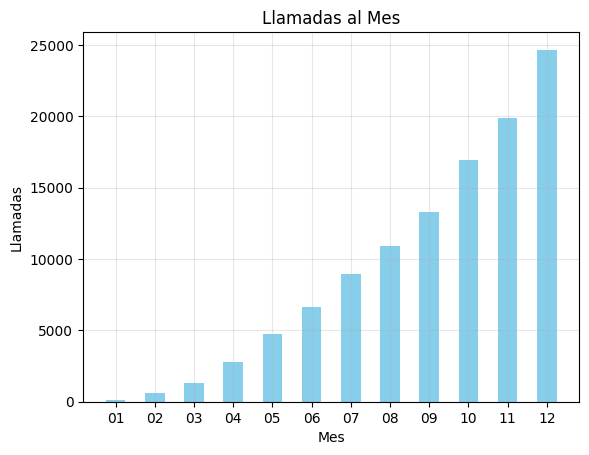

In [26]:
# Visualizo la información en una gráfica de barras.

plt_users_calls = df_users_calls[["month","call_id"]]
plt_users_calls = pd.DataFrame(plt_users_calls).sort_values(by="month").reset_index(drop = True)
plt_users_calls = plt_users_calls.groupby("month")["call_id"].sum().reset_index()

plt_uc = plt.bar(plt_users_calls["month"], plt_users_calls["call_id"], width = .5, data = plt_users_calls, color = "skyblue")
plt.title('Llamadas al Mes')
plt.xlabel('Mes')
plt.ylabel('Llamadas')
plt.grid(True, alpha = 0.3)
plt.show()

In [27]:
df_users_calls

,user_id,call_date,duration,call_id,month
0,1000,2018-12-26,5,1,12
1,1000,2018-12-26,10,1,12
2,1000,2018-12-27,6,2,12
3,1000,2018-12-27,9,1,12
4,1000,2018-12-27,14,1,12
...,...,...,...,...,...
104657,1499,2018-12-29,8,1,12
104658,1499,2018-12-29,14,1,12
104659,1499,2018-12-30,5,1,12
104660,1499,2018-12-31,17,1,12


In [28]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

df_users_durat = df_users.merge(df_calls, on = "user_id", how = "inner")
df_users_durat["call_date"] = df_users_durat["call_date"].dt.strftime("%Y-%m")
df_users_durat = pd.DataFrame(df_users_durat.groupby(["user_id", "call_date"])["duration"].sum().reset_index())
df_users_durat["call_date"] = pd.to_datetime(df_users_durat["call_date"], format = "%Y-%m-%d")
df_users_durat["month"] = (df_users_durat["call_date"].dt.strftime("%m"))
df_users_durat["month"] = pd.to_datetime(df_users_durat["month"], format = "%m").dt.strftime("%m")
df_users_durat.head()

,user_id,call_date,duration,month
0,1000,2018-12-01,116.83,12
1,1001,2018-08-01,171.14,08
2,1001,2018-09-01,297.69,09
3,1001,2018-10-01,374.11,10
4,1001,2018-11-01,404.59,11


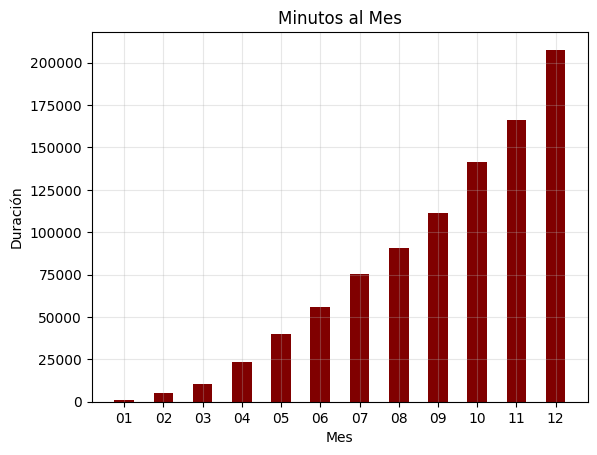

In [29]:
# Visualizo la información en una gráfica de barras.

plt_users_durat = df_users_durat[["month","duration"]]
plt_users_durat = pd.DataFrame(plt_users_durat).sort_values(by="month").reset_index(drop = True)
plt_users_durat = plt_users_durat.groupby("month")["duration"].sum().reset_index()

plt_ud = plt.bar(plt_users_durat["month"], plt_users_durat["duration"], width = .5, data = plt_users_durat, color = "maroon")
plt.title('Minutos al Mes')
plt.xlabel('Mes')
plt.ylabel('Duración')
plt.grid(True, alpha = 0.3)

In [30]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

df_users_messa = df_users.merge(df_messa, on = "user_id", how = "inner")
df_users_messa["message_date"] = df_users_messa["message_date"].dt.strftime("%Y-%m-%d")
df_users_messa = pd.DataFrame(df_users_messa.groupby(["user_id", "message_date"])["message_id"].count().reset_index())
df_users_messa["message_date"] = pd.to_datetime(df_users_messa["message_date"], format = "%Y-%m-%d")
df_users_messa["month"] = (df_users_messa["message_date"].dt.strftime("%m"))
df_users_messa["month"] = pd.to_datetime(df_users_messa["month"], format = "%m").dt.strftime("%m")
df_users_messa.head(10)

,user_id,message_date,message_id,month
0,1000,2018-12-25,1,12
1,1000,2018-12-26,1,12
2,1000,2018-12-27,3,12
3,1000,2018-12-28,1,12
4,1000,2018-12-29,1,12
5,1000,2018-12-30,1,12
6,1000,2018-12-31,3,12
7,1001,2018-08-14,1,08
8,1001,2018-08-15,4,08
9,1001,2018-08-16,2,08


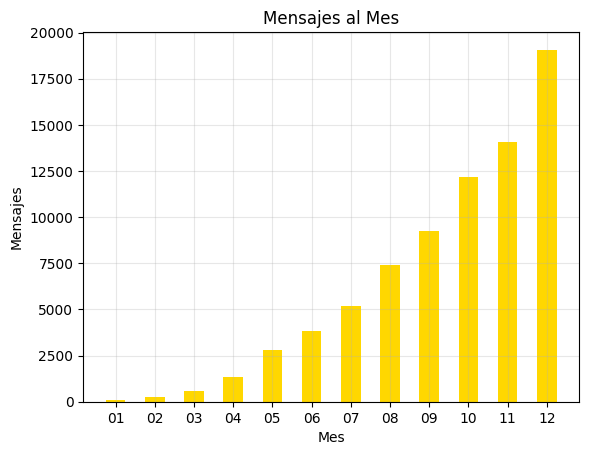

In [31]:
# Visualizo la información en una gráfica de barras.

plt_users_messa = df_users_messa[["month","message_id"]]
plt_users_messa = pd.DataFrame(plt_users_messa).sort_values(by="month").reset_index(drop = True)
plt_users_messa = plt_users_messa.groupby("month")["message_id"].sum().reset_index()

plt_um = plt.bar(plt_users_messa["month"], plt_users_messa["message_id"], width = .5, data = plt_users_messa, color = "gold")
plt.title('Mensajes al Mes')
plt.xlabel('Mes')
plt.ylabel('Mensajes')
plt.grid(True, alpha = 0.3)

In [32]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

df_users_inter = df_users.merge(df_inter, on = "user_id", how = "inner")
df_users_inter["session_date"] = df_users_inter["session_date"].dt.strftime("%Y-%m-%d")
df_users_inter = pd.DataFrame(df_users_inter.groupby(["user_id", "session_date"])["mb_used"].sum().reset_index())
df_users_inter["session_date"] = pd.to_datetime(df_users_inter["session_date"], format = "%Y-%m-%d")
df_users_inter["month"] = (df_users_inter["session_date"].dt.strftime("%m"))
df_users_inter["month"] = pd.to_datetime(df_users_inter["month"], format = "%m").dt.strftime("%m")
df_users_inter.head(10)

,user_id,session_date,mb_used,month
0,1000,2018-08-24,284.68,08
1,1000,2018-10-28,501.53,10
2,1000,2018-11-04,16.97,11
3,1000,2018-11-27,135.18,11
4,1000,2018-12-09,656.04,12
5,1000,2018-12-13,761.92,12
6,1000,2018-12-26,270.99,12
7,1000,2018-12-27,880.22,12
8,1000,2018-12-28,660.40,12
9,1000,2018-12-29,89.86,12


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

En el bloque de código siguiente hice la conversión y redondeo de MB. Decidí hacerlo en una nueva columna "gb_used".

Ajusté la gráfica para usar esa nueva columna.

</div>

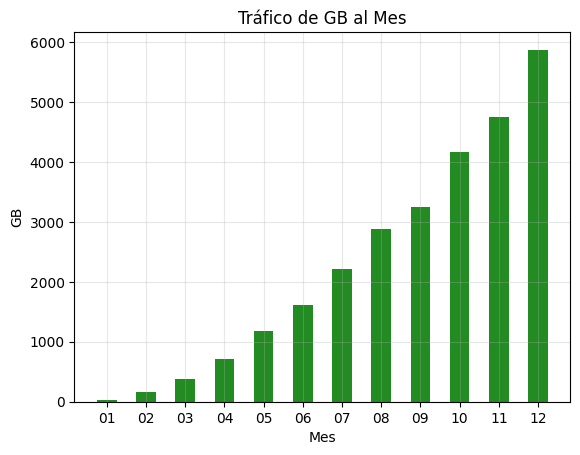

In [33]:
# Visualizo la información en una gráfica de barras.

plt_users_inter = df_users_inter[["month","mb_used"]]
plt_users_inter = pd.DataFrame(plt_users_inter).sort_values(by="month").reset_index(drop = True)
plt_users_inter = plt_users_inter.groupby("month")["mb_used"].sum().reset_index()
plt_users_inter["gb_used"] = (plt_users_inter["mb_used"]/1024).apply(mt.ceil)

plt_ui = plt.bar(plt_users_inter["month"], plt_users_inter["gb_used"], data = plt_users_inter, width = .5, color = "forestgreen")
plt.title('Tráfico de GB al Mes')
plt.xlabel('Mes')
plt.ylabel('GB')
plt.grid(True, alpha = 0.3)

[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [34]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month.

# Me deshago de información que no considero relevante para esta parte del ejercicio.
# La fecha exacta creo que no sirve, con el mes basta. El id de llamada lo reemplazaré con un simple conteo.

total_calls_data = df_users_calls.drop(["call_date", "call_id"], axis = 1)
total_calls_data

,user_id,duration,month
0,1000,5,12
1,1000,10,12
2,1000,6,12
3,1000,9,12
4,1000,14,12
...,...,...,...
104657,1499,8,12
104658,1499,14,12
104659,1499,5,12
104660,1499,17,12


In [35]:
# Sumo la duración de las llamadas y las cuento en base al usuario y al mes para no manejar tanta información.
total_calls_durat = df_users_calls.groupby(["user_id", "month"])["duration"].sum().reset_index()
total_calls_count = df_users_calls.groupby(["user_id", "month"])["duration"].count().reset_index().rename(columns = {"duration":"call_count"})
total_calls_count = total_calls_count.drop(["user_id","month"], axis = "columns") # Elimino columnas repetidas que no necesitaré en el DF final.

total_calls = pd.concat([total_calls_durat, total_calls_count], axis = "columns")
total_calls

,user_id,month,duration,call_count
0,1000,12,112,14
1,1001,08,182,22
2,1001,09,315,38
3,1001,10,387,46
4,1001,11,404,46
...,...,...,...,...
2251,1498,12,339,32
2252,1499,09,322,33
2253,1499,10,385,41
2254,1499,11,300,38


In [36]:
# Hago el mismo resumen con los mensajes para reducir el número de filas. Como ya había cambiado el "message_id" a un conteo,
#no será necesario hacer ese conteo; en cambio lo sumaré y le cambiaré el nombre a esa columna.

total_messa = df_users_messa.drop("message_date", axis = 1)
total_messa = total_messa.groupby(["user_id", "month"])["message_id"].sum().reset_index().rename(columns = {"message_id":"message_count"})
total_messa

,user_id,month,message_count
0,1000,12,11
1,1001,08,30
2,1001,09,44
3,1001,10,53
4,1001,11,36
...,...,...,...
1801,1496,09,21
1802,1496,10,18
1803,1496,11,13
1804,1496,12,11


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

Aquí hice nuevamente la nueva columna "gb_used".
</div>

In [37]:
# Hago el mismo resumen con el uso de internet para reducir el número de filas.

total_inter = df_users_inter.drop("session_date", axis = 1)
total_inter = total_inter.groupby(["user_id", "month"])["mb_used"].sum().reset_index()
total_inter["gb_used"] = (total_inter["mb_used"]/1024).apply(mt.ceil)
total_inter = total_inter.drop("mb_used", axis = 1)
total_inter

,user_id,month,gb_used
0,1000,08,1
1,1000,10,1
2,1000,11,1
3,1000,12,4
4,1001,08,5
...,...,...,...
2892,1497,07,2
2893,1497,08,2
2894,1497,09,3
2895,1497,10,3


In [38]:
# Fusiono toda la información en una sola DataFrame.

total_data = total_calls.merge(total_messa, on = ["user_id", "month"], how = "outer")
total_data = total_data.merge(total_inter, on = ["user_id", "month"], how = "outer")
total_data

,user_id,month,duration,call_count,message_count,gb_used
0,1000,12,112.0,14.0,11.0,4.0
1,1001,08,182.0,22.0,30.0,5.0
2,1001,09,315.0,38.0,44.0,13.0
3,1001,10,387.0,46.0,53.0,19.0
4,1001,11,404.0,46.0,36.0,16.0
...,...,...,...,...,...,...
3562,1497,07,NaN,NaN,NaN,2.0
3563,1497,08,NaN,NaN,NaN,2.0
3564,1497,09,NaN,NaN,NaN,3.0
3565,1497,10,NaN,NaN,NaN,3.0


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Recuerda que, según el enunciado del proyecto, los valores de duración de llamadas y consumo de internet deben redondearse hacia arriba, ya que el cobro se hace por minuto y GB completo. Para esto debes tener en cuenta lo siguiente:

* **Llamadas:** Primero realiza el redondeo hacia arriba de los minutos para cada llamada y luego sumas los minutos totales por usuario para cada mes.

* **Internet:** Primero sumas el consumo total en MB para cada usuario por mes, luego conviertes ese valor a GB y finalmente realizas el redondeo hacia arriba.

Los valores finales que obtienes para cada usuario, los comparas con los minutos y GB incluidos en cada plan, con el fin de establecer si hubo un exceso en el consumo y hacer el cobro respectivo.

</div>

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

Aquí cambié mi código para llamar a la nueva columna "gb_used".
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteración)</b> <a class=“tocSkip”></a>

Excelente trabajo con los ajustes Ricardo

</div>

In [39]:
# Añade la información de la tarifa

df_users_plan = df_users[["user_id", "plan"]]
total_data_plan = total_data.merge(df_users_plan, on = "user_id", how = "outer")

# Ordeno las columnas en un nuevo DataFrame para que el plan sea la 2a columna.
data_summary = total_data_plan[["user_id", "plan", "month", "call_count", "duration", "message_count", "gb_used"]]
data_summary

,user_id,plan,month,call_count,duration,message_count,gb_used
0,1000.0,ultimate,12,14.0,112.0,11.0,4.0
1,1000.0,ultimate,08,NaN,NaN,NaN,1.0
2,1000.0,ultimate,10,NaN,NaN,NaN,1.0
3,1000.0,ultimate,11,NaN,NaN,NaN,1.0
4,1001.0,surf,08,22.0,182.0,30.0,5.0
...,...,...,...,...,...,...,...
3573,1307.0,surf,NaN,NaN,NaN,NaN,NaN
3574,1319.0,surf,NaN,NaN,NaN,NaN,NaN
3575,1378.0,surf,NaN,NaN,NaN,NaN,NaN
3576,1463.0,ultimate,NaN,NaN,NaN,NaN,NaN


In [40]:
# Eliminaré las filas que no tienen información relevante. Verificaré que este nuevo DataFrame no tenga errores de tupo de datos.

data_summary_01 = data_summary.dropna(subset=["month"])
data_summary_01.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3567 entries, 0 to 3566
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   user_id        3567 non-null   float64 
 1   plan           3567 non-null   category
 2   month          3567 non-null   object  
 3   call_count     2256 non-null   float64 
 4   duration       2256 non-null   float64 
 5   message_count  1806 non-null   float64 
 6   gb_used        2897 non-null   float64 
dtypes: category(1), float64(5), object(1)
memory usage: 198.7+ KB


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

Aquí cambié mi código para llamar a la nueva columna "gb_used".
</div>

In [41]:
# Cambio a tipos de datos adecuados y elimino los datos nulos.

data_summary_01["month"] = data_summary_01["month"].astype("category")
data_summary_01["user_id"] = data_summary_01["user_id"].astype("int")
data_summary_01["call_count"] = data_summary_01["call_count"].fillna(0)
data_summary_01["call_count"] = data_summary_01["call_count"].astype("int")
data_summary_01["duration"] = data_summary_01["duration"].fillna(0)
data_summary_01["message_count"] = data_summary_01["message_count"].fillna(0)
data_summary_01["message_count"] = data_summary_01["message_count"].astype("int")
data_summary_01["gb_used"] = data_summary_01["gb_used"].fillna(0)
data_summary_01.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3567 entries, 0 to 3566
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   user_id        3567 non-null   int64   
 1   plan           3567 non-null   category
 2   month          3567 non-null   category
 3   call_count     3567 non-null   int64   
 4   duration       3567 non-null   float64 
 5   message_count  3567 non-null   int64   
 6   gb_used        3567 non-null   float64 
dtypes: category(2), float64(2), int64(3)
memory usage: 174.7 KB


/tmp/ipykernel_1575/4025198300.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_summary_01["month"] = data_summary_01["month"].astype("category")
/tmp/ipykernel_1575/4025198300.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_summary_01["user_id"] = data_summary_01["user_id"].astype("int")
/tmp/ipykernel_1575/4025198300.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in 

In [42]:
data_summary_01

,user_id,plan,month,call_count,duration,message_count,gb_used
0,1000,ultimate,12,14,112.0,11,4.0
1,1000,ultimate,08,0,0.0,0,1.0
2,1000,ultimate,10,0,0.0,0,1.0
3,1000,ultimate,11,0,0.0,0,1.0
4,1001,surf,08,22,182.0,30,5.0
...,...,...,...,...,...,...,...
3562,1349,surf,05,0,0.0,0,10.0
3563,1349,surf,06,0,0.0,0,15.0
3564,1349,surf,07,0,0.0,0,7.0
3565,1349,surf,08,0,0.0,0,16.0


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [43]:
data_summary_01.loc[[500]]["plan"]

500    surf
Name: plan, dtype: category
Categories (2, object): ['surf', 'ultimate']

In [44]:
# Calcula el ingreso mensual para cada usuario

# Agrego una columna para ingresos de llamadas en base a los parámetros de cada plan.
data_summary_01["ingresos_llamadas"] =  np.where(data_summary_01["plan"] == "surf", (np.where(data_summary_01["duration"] > 500, (data_summary_01["duration"] - 500) * 0.03, 0)), (np.where(data_summary_01["duration"] > 3000, (data_summary_01["duration"] - 3000) * 0.01, 0)))
# Redondeo a 2 decimales:
data_summary_01["ingresos_llamadas"] = data_summary_01["ingresos_llamadas"].apply(lambda x: round(x, 2))

# Muestro resultados mayores a 0 en la nueva columna para verificar que funcionó la fórmula.
data_summary_01[data_summary_01["ingresos_llamadas"]>0]

# Hubo ingresos solamente en el plan "surf" y solo en 484 meses por usuario.
# Comprobé lo primero con: data_summary_01[data_summary_01["duration"]>3000], el cual dio 0 resultados.

/tmp/ipykernel_1575/499630389.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_summary_01["ingresos_llamadas"] =  np.where(data_summary_01["plan"] == "surf", (np.where(data_summary_01["duration"] > 500, (data_summary_01["duration"] - 500) * 0.03, 0)), (np.where(data_summary_01["duration"] > 3000, (data_summary_01["duration"] - 3000) * 0.01, 0)))
/tmp/ipykernel_1575/499630389.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_summary_01["ingresos_llamadas"] = data_summary_01["ingresos_llamadas"

,user_id,plan,month,call_count,duration,message_count,gb_used,ingresos_llamadas
14,1003,surf,12,100,959.0,50,6.0,13.77
43,1007,surf,10,66,616.0,59,6.0,3.48
45,1007,surf,12,69,607.0,50,30.0,3.21
55,1009,surf,06,88,770.0,0,0.0,8.10
56,1009,surf,07,96,835.0,0,0.0,10.05
...,...,...,...,...,...,...,...,...
3427,1488,surf,11,87,738.0,0,0.0,7.14
3428,1488,surf,12,70,656.0,0,0.0,4.68
3449,1491,surf,10,60,566.0,51,38.0,1.98
3464,1494,surf,10,56,585.0,38,4.0,2.55


In [45]:
# Agrego columna para ingresos por mensajes extra de acuerdo a cada plan.

data_summary_01["ingresos_mensajes"] =  np.where(data_summary_01["plan"] == "surf", (np.where(data_summary_01["message_count"] > 50, (data_summary_01["message_count"] - 50) * 0.03, 0)), (np.where(data_summary_01["message_count"] > 1000, (data_summary_01["message_count"] - 1000) * 0.01, 0)))
# Redondeo a 2 decimales:
data_summary_01["ingresos_mensajes"] = data_summary_01["ingresos_mensajes"].apply(lambda x: round(x, 2))

# Muestro resultados mayores a 0 en la nueva columna para verificar que funcionó la fórmula.
data_summary_01[data_summary_01["ingresos_mensajes"]>0]

# Hubo ingresos solamente en el plan "surf" y solo en 340 meses por usuario.
# Comprobé lo primero con: data_summary_01[data_summary_01["message_count"]>1000], el cual dio 0 resultados.

/tmp/ipykernel_1575/730322630.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_summary_01["ingresos_mensajes"] =  np.where(data_summary_01["plan"] == "surf", (np.where(data_summary_01["message_count"] > 50, (data_summary_01["message_count"] - 50) * 0.03, 0)), (np.where(data_summary_01["message_count"] > 1000, (data_summary_01["message_count"] - 1000) * 0.01, 0)))
/tmp/ipykernel_1575/730322630.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_summary_01["ingresos_mensajes"] = data_summary_01["

,user_id,plan,month,call_count,duration,message_count,gb_used,ingresos_llamadas,ingresos_mensajes
6,1001,surf,10,46,387.0,53,19.0,0.00,0.09
41,1007,surf,08,53,438.0,51,10.0,0.00,0.03
43,1007,surf,10,66,616.0,59,6.0,3.48,0.27
84,1014,surf,12,113,1035.0,64,4.0,16.05,0.42
91,1015,surf,12,12,96.0,68,6.0,0.00,0.54
...,...,...,...,...,...,...,...,...,...
3546,1194,surf,11,0,0.0,62,18.0,0.00,0.36
3547,1194,surf,12,0,0.0,56,18.0,0.00,0.18
3557,1349,surf,10,0,0.0,76,8.0,0.00,0.78
3558,1349,surf,11,0,0.0,72,7.0,0.00,0.66


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

Aquí cambié mi código para llamar a la nueva columna "gb_used", y le cambié el nombre a la columna de ingresos. Eliminé la parte que convertía a GB en este código.
</div>

In [46]:
# Agrego columna para ingresos por Mb extra de acuerdo a cada plan.

data_summary_01["ingresos_gb"] =  np.where(data_summary_01["plan"] == "surf", (np.where(data_summary_01["gb_used"] > 15, (data_summary_01["gb_used"] - 15) * 10, 0)), (np.where(data_summary_01["gb_used"] > 30, (data_summary_01["gb_used"] - 30) * 7, 0)))
# Redondeo a 2 decimales, aunque no es necesario pero no quiero mostrar 0's de más:
data_summary_01["ingresos_gb"] = data_summary_01["ingresos_gb"].apply(lambda x: round(x, 2))

# Muestro resultados mayores a 0 en la nueva columna para verificar que funcionó la fórmula.
data_summary_01[data_summary_01["ingresos_gb"]>0]

# Hubo ingresos para ambos planes pero solo en 410 meses por usuario.
# Comprobé lo primero con: data_summary_01[data_summary_01["mb_used"]>30720], el cual dio 0 resultados.

/tmp/ipykernel_1575/1572601973.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_summary_01["ingresos_gb"] =  np.where(data_summary_01["plan"] == "surf", (np.where(data_summary_01["gb_used"] > 15, (data_summary_01["gb_used"] - 15) * 10, 0)), (np.where(data_summary_01["gb_used"] > 30, (data_summary_01["gb_used"] - 30) * 7, 0)))
/tmp/ipykernel_1575/1572601973.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_summary_01["ingresos_gb"] = data_summary_01["ingresos_gb"].apply(lambda x: round(x, 2))


,user_id,plan,month,call_count,duration,message_count,gb_used,ingresos_llamadas,ingresos_mensajes,ingresos_gb
6,1001,surf,10,46,387.0,53,19.0,0.00,0.09,40.0
7,1001,surf,11,46,404.0,36,16.0,0.00,0.00,10.0
8,1001,surf,12,42,386.0,44,17.0,0.00,0.00,20.0
24,1004,surf,12,42,417.0,31,32.0,0.00,0.00,170.0
45,1007,surf,12,69,607.0,50,30.0,3.21,0.00,150.0
...,...,...,...,...,...,...,...,...,...,...
3533,1131,surf,12,0,0.0,33,22.0,0.00,0.00,70.0
3543,1194,surf,08,0,0.0,10,16.0,0.00,0.00,10.0
3546,1194,surf,11,0,0.0,62,18.0,0.00,0.36,30.0
3547,1194,surf,12,0,0.0,56,18.0,0.00,0.18,30.0


In [47]:
# Agrego la columna de la tarifa mensual de cada plan.

df_plans_filtered = df_plans[["plan_name", "usd_monthly_pay"]]
df_plans_filtered.rename(columns = {"plan_name":"plan"}, inplace = True)

data_summary_02 = data_summary_01.merge(df_plans_filtered, on = "plan")

data_summary_02

/.venv/lib/python3.9/site-packages/pandas/core/frame.py:4441: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().rename(


,user_id,plan,month,call_count,duration,message_count,gb_used,ingresos_llamadas,ingresos_mensajes,ingresos_gb,usd_monthly_pay
0,1000,ultimate,12,14,112.0,11,4.0,0.0,0.0,0.0,70.0
1,1000,ultimate,08,0,0.0,0,1.0,0.0,0.0,0.0,70.0
2,1000,ultimate,10,0,0.0,0,1.0,0.0,0.0,0.0,70.0
3,1000,ultimate,11,0,0.0,0,1.0,0.0,0.0,0.0,70.0
4,1006,ultimate,11,2,10.0,15,7.0,0.0,0.0,0.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...
3562,1349,surf,05,0,0.0,0,10.0,0.0,0.0,0.0,20.0
3563,1349,surf,06,0,0.0,0,15.0,0.0,0.0,0.0,20.0
3564,1349,surf,07,0,0.0,0,7.0,0.0,0.0,0.0,20.0
3565,1349,surf,08,0,0.0,0,16.0,0.0,0.0,10.0,20.0


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

Aquí cambié mi código para llamar a la nueva columna "ingresos_gb".
</div>

In [48]:
# Finalmente, agrego una nueva columna con el total y renombro el DataFrame.
# Esa última columna es el ingreso mensual por usuario.

data_summary_02["ingresos_totales"] = data_summary_02["ingresos_llamadas"] + data_summary_02["ingresos_mensajes"] + data_summary_02["ingresos_gb"] + data_summary_02["usd_monthly_pay"]

data_summary_final = data_summary_02
data_summary_final

,user_id,plan,month,call_count,duration,message_count,gb_used,ingresos_llamadas,ingresos_mensajes,ingresos_gb,usd_monthly_pay,ingresos_totales
0,1000,ultimate,12,14,112.0,11,4.0,0.0,0.0,0.0,70.0,70.0
1,1000,ultimate,08,0,0.0,0,1.0,0.0,0.0,0.0,70.0,70.0
2,1000,ultimate,10,0,0.0,0,1.0,0.0,0.0,0.0,70.0,70.0
3,1000,ultimate,11,0,0.0,0,1.0,0.0,0.0,0.0,70.0,70.0
4,1006,ultimate,11,2,10.0,15,7.0,0.0,0.0,0.0,70.0,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3562,1349,surf,05,0,0.0,0,10.0,0.0,0.0,0.0,20.0,20.0
3563,1349,surf,06,0,0.0,0,15.0,0.0,0.0,0.0,20.0,20.0
3564,1349,surf,07,0,0.0,0,7.0,0.0,0.0,0.0,20.0,20.0
3565,1349,surf,08,0,0.0,0,16.0,0.0,0.0,10.0,20.0,30.0


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

La lógica de cálculo del cobro mensual es correcta en general, solo necesitas ajustar el redondeo como te mencioné antes. Asegúrate de hacer la estimación del cobro por el consumo de internet comparando los datos en GB, además es importante considerar el plan de cada usuario, el costo del plan base y los cargos por consumos adicionales para calcular correctamente el monto final.

</div>

## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

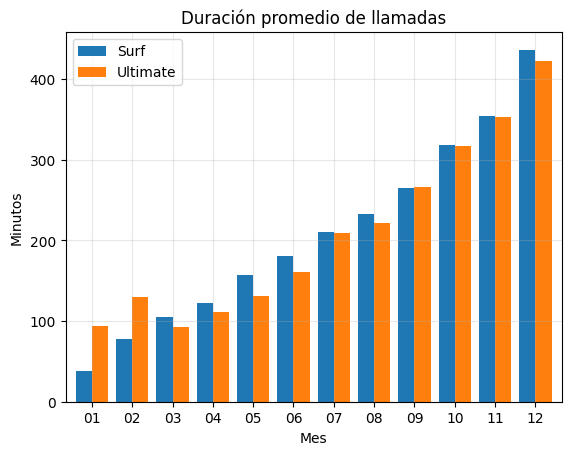

In [49]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

# Agrupo por mes y por plan, calculo el promedio de la duración, y creo una gráfica que tenga la data de ambos planes cada mes.
df_llama_planmes = data_summary_final.groupby(["plan", "month"])["duration"].mean().reset_index()
pvt_llama_planmes = df_llama_planmes.pivot(index = "month", columns = "plan", values = "duration")

pvt_llama_planmes.plot(kind = "bar", rot = 0, width = 0.8)
plt.title("Duración promedio de llamadas")
plt.xlabel("Mes")
plt.ylabel("Minutos")
plt.legend(["Surf", "Ultimate"])
plt.grid(True, alpha = 0.3)

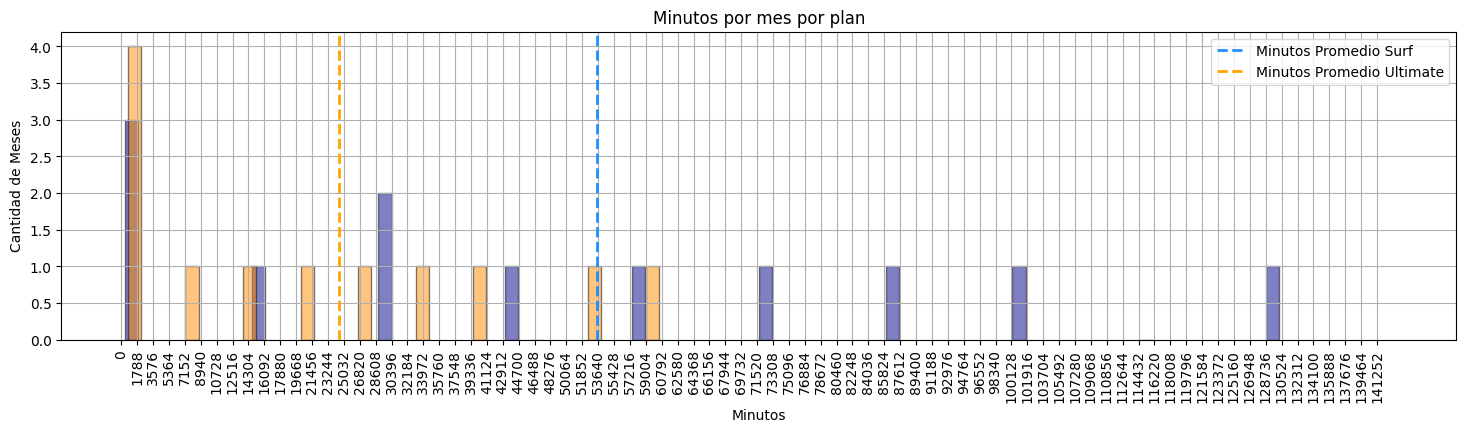

In [50]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

df_llama_planmes_mins = data_summary_final.groupby(["plan", "month"])["duration"].sum().reset_index()

#df_llama_planmes_mins = data_summary_final.groupby(["plan", "month"])["duration"].sum().reset_index()
plt.figure(figsize=(18, 4))
df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="surf"]["duration"].hist(width = 1500, edgecolor = "black", color = "darkblue", alpha = 0.5)
df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="ultimate"]["duration"].hist(width = 1500, edgecolor = "black", color = "darkorange", alpha = 0.5)
plt.title("Minutos por mes por plan")
plt.xlabel("Minutos")
plt.ylabel("Cantidad de Meses")
plt.legend(["Surf", "Ultimate"])
plt.xticks(np.arange(0,143000,1788), rotation = 90)
plt.axvline(df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="surf"]["duration"].mean(), color = 'dodgerblue', linestyle = "--", linewidth = 2)
plt.axvline(df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="ultimate"]["duration"].mean(), color = 'orange', linestyle = "--", linewidth = 2)
plt.legend(["Minutos Promedio Surf", "Minutos Promedio Ultimate"])


[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [51]:
# Calcula la media y la varianza de la duración mensual de llamadas.

#print(df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="surf"]["duration"].describe())
surf_mean = round(df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="surf"]["duration"].mean(), 2)
surf_var = round(np.std(df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="surf"]["duration"], ddof = 1) ** 2,2)
ultimate_mean = round(df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="ultimate"]["duration"].mean(), 2)
ultimate_var = round(np.std(df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="ultimate"]["duration"], ddof = 1) ** 2,2)

print(f"Promedio de plan Surf: ", surf_mean)
print(f"Varianza de plan Surf: ", surf_var)
print("")
print(f"Promedio de plan Ultimate: ", ultimate_mean)
print(f"Varianza de plan Ultimate: ", ultimate_var)

Promedio de plan Surf:  53522.08
Varianza de plan Surf:  2174721098.45

Promedio de plan Ultimate:  24533.5
Varianza de plan Ultimate:  467318839.55


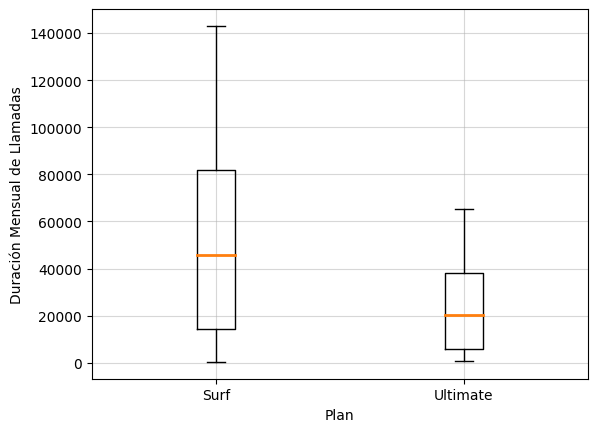

In [52]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

both_durations = [df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="surf"]["duration"], df_llama_planmes_mins[df_llama_planmes_mins["plan"]=="ultimate"]["duration"]]
plt.boxplot(both_durations, labels = ["Surf", "Ultimate"], medianprops=dict(linewidth = 2))
plt.xlabel("Plan")
plt.ylabel("Duración Mensual de Llamadas")
plt.grid(alpha = 0.5)

In [53]:
# Comparo ambos ingresos totales para analizarlos tomando en cuenta el pago mensual base de $20.00 y $70.00 para Surf y Ultimate respectivamente.

print(data_summary_final[data_summary_final["plan"]=="surf"]["ingresos_totales"].describe())
print("")
print(data_summary_final[data_summary_final["plan"]=="ultimate"]["ingresos_totales"].describe())

# También quiero ver el total de ingresos por cada plan.
print("")
print(f"Ingresos totales de Surf: ", data_summary_final[data_summary_final["plan"]=="surf"]["ingresos_totales"].sum())
print("")
print(f"Ingresos totales de Ultimate: ", data_summary_final[data_summary_final["plan"]=="ultimate"]["ingresos_totales"].sum())

count    2421.000000
mean       39.589682
std        72.301764
min        20.000000
25%        20.000000
50%        20.000000
75%        21.980000
max      1063.600000
Name: ingresos_totales, dtype: float64

count    1146.000000
mean       75.253054
std        30.681269
min        70.000000
25%        70.000000
50%        70.000000
75%        70.000000
max       448.000000
Name: ingresos_totales, dtype: float64

Ingresos totales de Surf:  95846.62

Ingresos totales de Ultimate:  86240.0


In [54]:
# Evaluo si el número de usuarios incrementó cada mes para asegurarme de que el aparente incremento mensual en consumo no sea por el incremento
#de usuarios.

users_month = data_summary_final.groupby(["plan", "month"])["user_id"].nunique().reset_index()
users_month

# Efectivamente, el número de usuarios creció durante el año.

,plan,month,user_id
0,surf,01,10
1,surf,02,33
2,surf,03,69
3,surf,04,136
4,surf,05,187
5,surf,06,221
6,surf,07,247
7,surf,08,271
8,surf,09,291
9,surf,10,306


In [55]:
# Reviso los ingresos por usuario y por mes de cada plan para ver si el comportamiento de los usuarios cambia mes a mes.

plan_month_llamprofit = data_summary_final.groupby(["plan", "month"])["ingresos_llamadas"].sum().reset_index()
plan_month_llam_profit = users_month.merge(plan_month_llamprofit[["plan", "month", "ingresos_llamadas"]], on = ["plan", "month"])
plan_month_llam_profit["ing_llam_por_usuarios"] = round(plan_month_llam_profit["ingresos_llamadas"] / plan_month_llam_profit["user_id"],2)
plan_month_llam_profit

# Ambos planes generan más ingresos los últimos meses del año, por lo tanto consumen más.

,plan,month,user_id,ingresos_llamadas,ing_llam_por_usuarios
0,surf,01,10,0.00,0.00
1,surf,02,33,7.47,0.23
2,surf,03,69,11.58,0.17
3,surf,04,136,37.92,0.28
4,surf,05,187,97.92,0.52
5,surf,06,221,121.89,0.55
6,surf,07,247,210.72,0.85
7,surf,08,271,200.25,0.74
8,surf,09,291,214.62,0.74
9,surf,10,306,340.65,1.11


(0.0, 2.5)

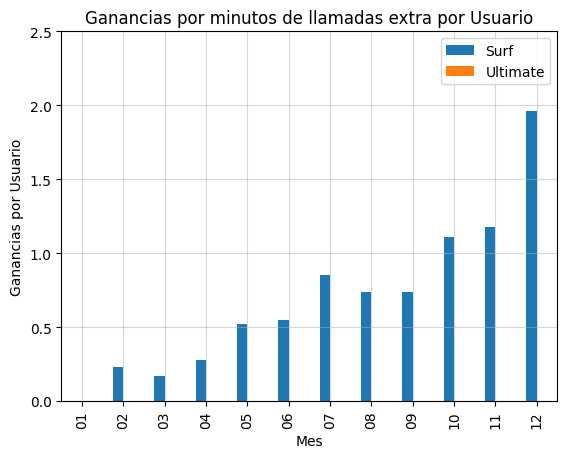

In [56]:
df_plan_month_llam_profit = plan_month_llam_profit.groupby(["plan", "month"])["ing_llam_por_usuarios"].sum().reset_index()
pvt_plan_month_llam_profit = pd.pivot(df_plan_month_llam_profit, index = "month", columns = "plan", values = "ing_llam_por_usuarios")

plt_plan_month_profit = pvt_plan_month_llam_profit.plot(kind = "bar")
plt.grid(alpha = 0.5)
plt.title("Ganancias por minutos de llamadas extra por Usuario")
plt.xlabel("Mes")
plt.ylabel("Ganancias por Usuario")
plt.legend(["Surf", "Ultimate"])
plt.ylim(0, 2.5)

# El mes con más consumo por usuario es Diciembre en el plan Surf, pero no hay consumo extra de llamadas para el plan Ultimate.

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

- Hay una diferencia evidente y significativa entre ambos planes. Los del plan "Surf" se exceden de los parámetros de llamadas límite cada mes salvo por Enero, mientras que los del plan "Ultimate" no se exceden. Esto es algo de esperarse porque Surf tiene menos minutos de llamadas, mensajes, y Mb disponibles dentro del paquete.
- La mayoría de los usuarios no se salen de sus límites de consumo incluidos en el plan. En el Surf, al menos la mitad están dentro de sus límites y, en el Ultimate, al menos 75%.
- La información del uso mensual de llamadas, mensajes, y Mb parece haber incrementado gradualmente cada mes, pero al revisar el número de usuarios se ve un incremento de 10 usuarios en Enero hasta 328 en Diciembre en el plan Surf, y de 8 en Enero hasta 155 en el plan Ultimate, lo cual forzosamente aumentará el consumo total.
- Después de revisar el consumo de minutos de llamadas extra por usuario cada mes, concluyo que efectivamente se consume más al final del año para usuarios Surf, pero no tanto más como aparentaban las gráficas anteriores que no comparaban el consumo por cada usuario, sino el total.
- El mes en el que más minutos de llamadas se consumen es en Diciembre para ambos planes, pero los de Ultimate no se exceden de sus minutos incluidos.

### Mensajes

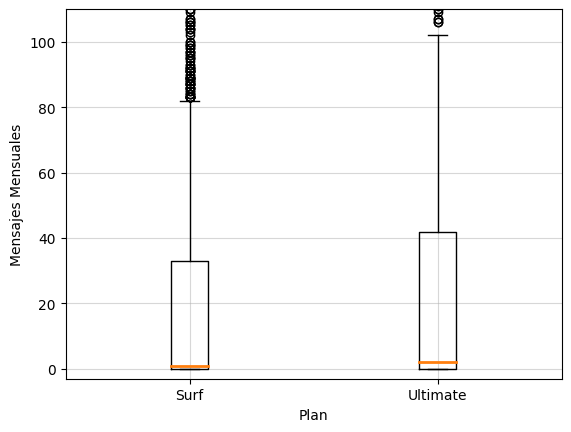

In [57]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

both_messa = [data_summary_final[data_summary_final["plan"]=="surf"]["message_count"], data_summary_final[data_summary_final["plan"]=="ultimate"]["message_count"]]

plt.boxplot(both_messa, labels = ["Surf", "Ultimate"], medianprops=dict(linewidth = 2))
plt.xlabel("Plan")
plt.ylabel("Mensajes Mensuales")
plt.ylim(-3, 110)
plt.grid(alpha = 0.5)

In [58]:
# Comparo el uso de mensajes para analizarlos.

print(data_summary_final[data_summary_final["plan"]=="surf"]["message_count"].describe())
print("")
print(data_summary_final[data_summary_final["plan"]=="ultimate"]["message_count"].describe())

# También quiero ver el total de ingresos extra de mensajes por cada plan.
print("")
print(f"Ingresos extra de mensajes totales de Surf: ", round(data_summary_final[data_summary_final["plan"]=="surf"]["ingresos_mensajes"].sum(),2))
print("")
print(f"Ingresos extra de mensajes totales de Ultimate: ", data_summary_final[data_summary_final["plan"]=="ultimate"]["ingresos_mensajes"].sum())

count    2421.000000
mean       20.245353
std        30.870031
min         0.000000
25%         0.000000
50%         1.000000
75%        33.000000
max       266.000000
Name: message_count, dtype: float64

count    1146.000000
mean       23.592496
std        32.994676
min         0.000000
25%         0.000000
50%         2.000000
75%        41.750000
max       166.000000
Name: message_count, dtype: float64

Ingresos extra de mensajes totales de Surf:  330.93

Ingresos extra de mensajes totales de Ultimate:  0.0


In [59]:
plan_month_messacount = data_summary_final.groupby(["plan", "month"])["message_count"].sum().reset_index()
plan_month_messa_count = users_month.merge(plan_month_messacount[["plan", "month", "message_count"]], on = ["plan", "month"])
plan_month_messa_count["cont_messa_por_usuarios"] = round(plan_month_messa_count["message_count"] / plan_month_messa_count["user_id"],2)
plan_month_messa_count

# Cada usuario envía más mensajes conforme avanza el año.

,plan,month,user_id,message_count,cont_messa_por_usuarios
0,surf,01,10,21,2.10
1,surf,02,33,108,3.27
2,surf,03,69,351,5.09
3,surf,04,136,870,6.40
4,surf,05,187,1849,9.89
5,surf,06,221,2454,11.10
6,surf,07,247,3271,13.24
7,surf,08,271,4662,17.20
8,surf,09,291,5968,20.51
9,surf,10,306,8020,26.21


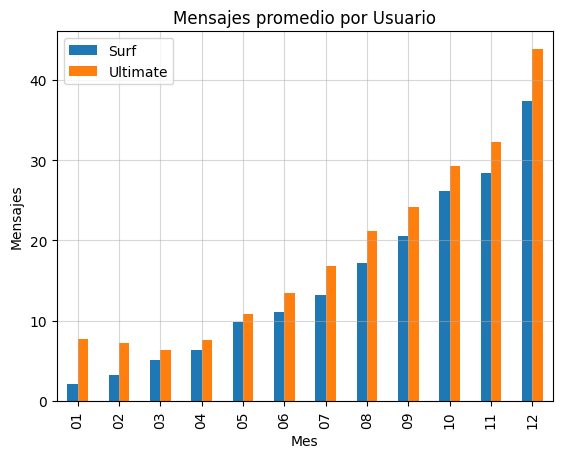

In [60]:
df_plan_month_messa_count = plan_month_messa_count.groupby(["plan", "month"])["cont_messa_por_usuarios"].sum().reset_index()
pvt_plan_month_messa_count = pd.pivot(df_plan_month_messa_count, index = "month", columns = "plan", values = "cont_messa_por_usuarios")

plt_plan_month_messa_count = pvt_plan_month_messa_count.plot(kind = "bar")
plt.grid(alpha = 0.5)
plt.title("Mensajes promedio por Usuario")
plt.xlabel("Mes")
plt.ylabel("Mensajes")
plt.legend(["Surf", "Ultimate"])

In [61]:
# Reviso los ingresos extra para ver si se exceden de su límite.

plan_month_messaprofit = data_summary_final.groupby(["plan", "month"])["ingresos_mensajes"].sum().reset_index()
plan_month_messa_profit = users_month.merge(plan_month_messaprofit[["plan", "month", "ingresos_mensajes"]], on = ["plan", "month"])
plan_month_messa_profit["ing_messa_por_usuarios"] = round(plan_month_messa_profit["ingresos_mensajes"] / plan_month_messa_profit["user_id"],2)
plan_month_messa_profit

# Cada usuario envía más mensajes conforme avanza el año.

,plan,month,user_id,ingresos_mensajes,ing_messa_por_usuarios
0,surf,01,10,0.00,0.00
1,surf,02,33,0.24,0.01
2,surf,03,69,0.39,0.01
3,surf,04,136,2.61,0.02
4,surf,05,187,9.66,0.05
5,surf,06,221,14.49,0.07
6,surf,07,247,17.58,0.07
7,surf,08,271,29.19,0.11
8,surf,09,291,36.09,0.12
9,surf,10,306,59.58,0.19


(0.0, 0.4)

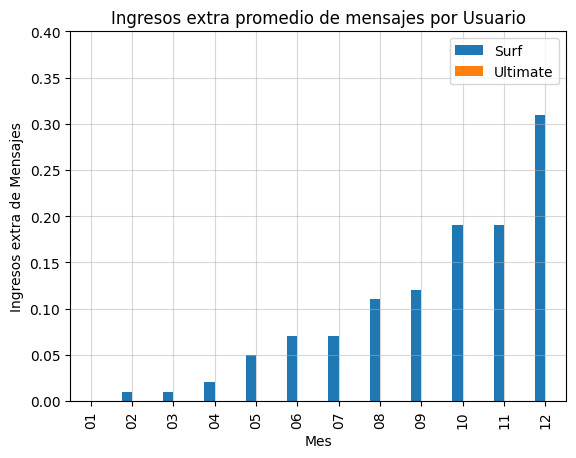

In [62]:
df_plan_month_messa_profit = plan_month_messa_profit.groupby(["plan", "month"])["ing_messa_por_usuarios"].sum().reset_index()
pvt_plan_month_messa_profit = pd.pivot(df_plan_month_messa_profit, index = "month", columns = "plan", values = "ing_messa_por_usuarios")

plt_plan_month_messa_profit = pvt_plan_month_messa_profit.plot(kind = "bar")
plt.grid(alpha = 0.5)
plt.title("Ingresos extra promedio de mensajes por Usuario")
plt.xlabel("Mes")
plt.ylabel("Ingresos extra de Mensajes")
plt.legend(["Surf", "Ultimate"])
plt.ylim(0,0.4)

# Nuevamente, solo los usuarios de Surf se exceden, pero por muy poco en promedio.

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

- Los usuarios se comportan de manera similar con sus mensajes que con sus llamadas; los usuarios de Ultimate no se exceden mientras que los de Surf sí.
- Aumenta el uso de mensajes conforme pasa el año, siendo nuevamente Diciembre el mes más activo para ambos planes.
- A diferencia de las llamadas, los mensajes se usan muchísimo menos; en ambos planes, el 50% de los usuarios en conjunto de cada plan usan menos de 3 mensajes al año.
- En cuanto a ingresos extra, solamente los usuarios de Surf generan $330.93 en total durante el año.

### Internet

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

En toda esta sección cambié mi código para llamar a las nuevas columna "gb_used" e "ingresos_gb".
</div>

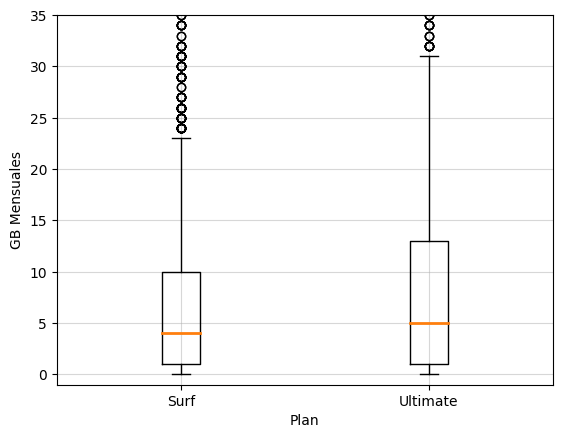

In [63]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

both_inter = [data_summary_final[data_summary_final["plan"]=="surf"]["gb_used"], data_summary_final[data_summary_final["plan"]=="ultimate"]["gb_used"]]

plt.boxplot(both_inter, labels = ["Surf", "Ultimate"], medianprops = dict(linewidth = 2))
plt.xlabel("Plan")
plt.ylabel("GB Mensuales")
plt.ylim(-1, 35)
plt.grid(alpha = 0.5)

In [64]:
# Comparo el uso de MB para analizarlos.

print(data_summary_final[data_summary_final["plan"]=="surf"]["gb_used"].describe())
print("")
print(data_summary_final[data_summary_final["plan"]=="ultimate"]["gb_used"].describe())

# También quiero ver el total de ingresos extra de mensajes por cada plan.
print("")
print(f"Ingresos extra de GB totales de Surf: ", data_summary_final[data_summary_final["plan"]=="surf"]["ingresos_gb"].sum())
print("")
print(f"Ingresos extra de GB totales de Ultimate: ", data_summary_final[data_summary_final["plan"]=="ultimate"]["ingresos_gb"].sum())

count    2421.000000
mean        7.610905
std        10.689871
min         0.000000
25%         1.000000
50%         4.000000
75%        10.000000
max       119.000000
Name: gb_used, dtype: float64

count    1146.000000
mean        8.959860
std        11.322588
min         0.000000
25%         1.000000
50%         5.000000
75%        13.000000
max        84.000000
Name: gb_used, dtype: float64

Ingresos extra de GB totales de Surf:  44830.0

Ingresos extra de GB totales de Ultimate:  6020.0


In [65]:
plan_month_mbsum = data_summary_final.groupby(["plan", "month"])["gb_used"].sum().reset_index()
plan_month_mb_sum = users_month.merge(plan_month_mbsum[["plan", "month", "gb_used"]], on = ["plan", "month"])
plan_month_mb_sum["uso_gb_por_usuarios"] = round(plan_month_mb_sum["gb_used"] / plan_month_mb_sum["user_id"],2)
plan_month_mb_sum

# Cada usuario utiliza más Mb conforme avanza el año.

,plan,month,user_id,gb_used,uso_gb_por_usuarios
0,surf,01,10,21.0,2.10
1,surf,02,33,123.0,3.73
2,surf,03,69,270.0,3.91
3,surf,04,136,501.0,3.68
4,surf,05,187,806.0,4.31
5,surf,06,221,1116.0,5.05
6,surf,07,247,1517.0,6.14
7,surf,08,271,1916.0,7.07
8,surf,09,291,2213.0,7.60
9,surf,10,306,2875.0,9.40


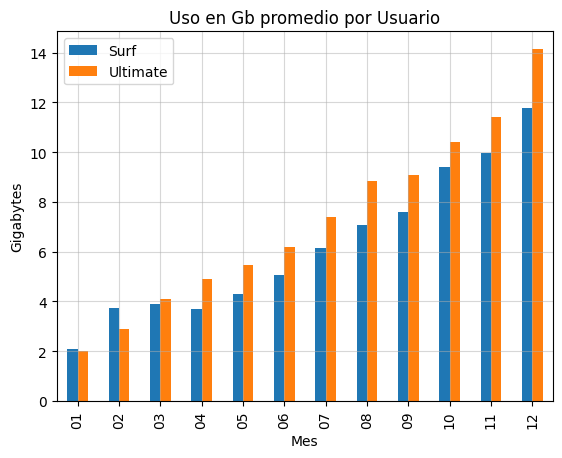

In [66]:
df_plan_month_mb_sum = plan_month_mb_sum.groupby(["plan", "month"])["uso_gb_por_usuarios"].sum().reset_index()
pvt_plan_month_mb_sum = pd.pivot(df_plan_month_mb_sum, index = "month", columns = "plan", values = "uso_gb_por_usuarios")

plt_plan_month_mb_sum = pvt_plan_month_mb_sum.plot(kind = "bar")
plt.grid(alpha = 0.5)
plt.title("Uso en Gb promedio por Usuario")
plt.xlabel("Mes")
plt.ylabel("Gigabytes")
plt.legend(["Surf", "Ultimate"])

In [67]:
# Reviso los ingresos extra por Gb para ver si se exceden de su límite.

plan_month_mbprofit = data_summary_final.groupby(["plan", "month"])["ingresos_gb"].sum().reset_index()
plan_month_mb_profit = users_month.merge(plan_month_mbprofit[["plan", "month", "ingresos_gb"]], on = ["plan", "month"])
plan_month_mb_profit["ing_gb_por_usuarios"] = round(plan_month_mb_profit["ingresos_gb"] / plan_month_mb_profit["user_id"],2)
plan_month_mb_profit

# Cada usuario utiliza más datos conforme avanza el año. Hay excedentes en ambos planes a diferencia de los mensajes y llamadas.

,plan,month,user_id,ingresos_gb,ing_gb_por_usuarios
0,surf,01,10,0.0,0.00
1,surf,02,33,80.0,2.42
2,surf,03,69,200.0,2.90
3,surf,04,136,30.0,0.22
4,surf,05,187,180.0,0.96
5,surf,06,221,670.0,3.03
6,surf,07,247,2070.0,8.38
7,surf,08,271,3430.0,12.66
8,surf,09,291,4520.0,15.53
9,surf,10,306,7980.0,26.08


(0.0, 55.0)

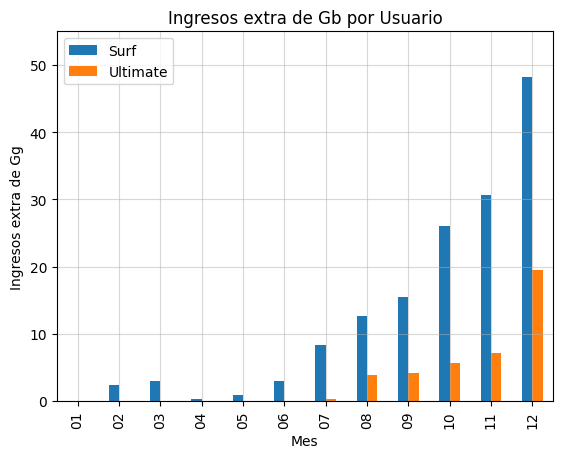

In [68]:
df_plan_month_mb_profit = plan_month_mb_profit.groupby(["plan", "month"])["ing_gb_por_usuarios"].sum().reset_index()
pvt_plan_month_mb_profit = pd.pivot(df_plan_month_mb_profit, index = "month", columns = "plan", values = "ing_gb_por_usuarios")

plt_plan_month_mb_profit = pvt_plan_month_mb_profit.plot(kind = "bar")
plt.grid(alpha = 0.5)
plt.title("Ingresos extra de Gb por Usuario")
plt.xlabel("Mes")
plt.ylabel("Ingresos extra de Gg")
plt.legend(["Surf", "Ultimate"])
plt.ylim(0,55)

# Ambos planes se exceden, pero los de Surf por más que los de Ultimate.

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

- Nuevamente, ambos tipos de usuario incrementan su consumo conforme avanza el año. En este caso, hay excesos en ambos planes, siendo Diciembre cuando más se exceden.
- Los del plan ultimate utilizan más MB, pero no se exceden tanto por tener un límite mayor que el plan Surf. Los primeros usan en promedio 8 GB mientras que los del plan Surf usan 7 GB en promedio al mes.
- Los usuarios de Surf generan mucho más ingresos por consumo extra por tener un límite de uso del 50% comparado con el de Ultimate.

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

Igualmente, en toda esta sección hice el ajuste necesario para el análisis de consumo/ingresos de internet.
</div>

In [69]:
print(f"Ingresos totales del plan Surf: $", data_summary_final[data_summary_final["plan"] == "surf"]["ingresos_totales"].sum())
print()
print(data_summary_final[data_summary_final["plan"] == "surf"]["ingresos_totales"].describe())
print()
print()
print(f"Ingresos totales del plan Ultimate: $", data_summary_final[data_summary_final["plan"] == "ultimate"]["ingresos_totales"].sum())
print()
print(data_summary_final[data_summary_final["plan"] == "ultimate"]["ingresos_totales"].describe())

Ingresos totales del plan Surf: $ 95846.62

count    2421.000000
mean       39.589682
std        72.301764
min        20.000000
25%        20.000000
50%        20.000000
75%        21.980000
max      1063.600000
Name: ingresos_totales, dtype: float64


Ingresos totales del plan Ultimate: $ 86240.0

count    1146.000000
mean       75.253054
std        30.681269
min        70.000000
25%        70.000000
50%        70.000000
75%        70.000000
max       448.000000
Name: ingresos_totales, dtype: float64


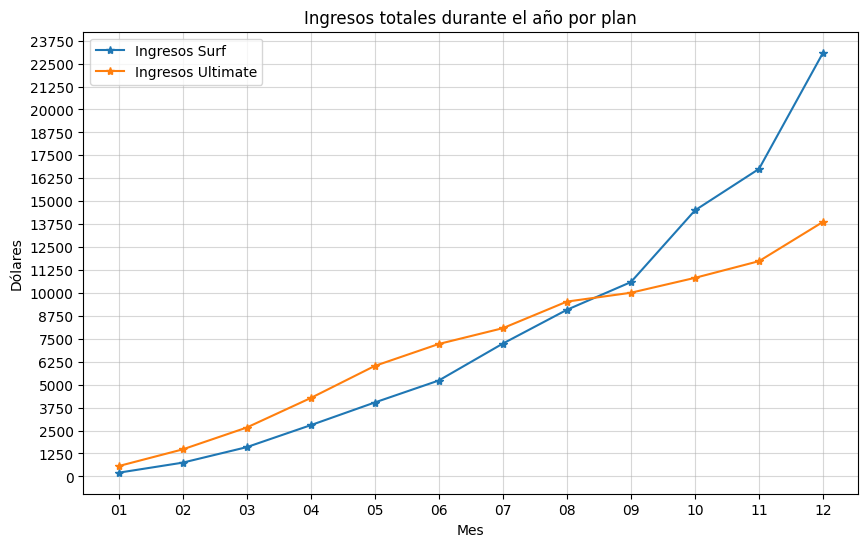

In [70]:
# Agrupo los ingresos de cada tipo por plan para evaluarlos por separado:
ingresos_surf = data_summary_final[data_summary_final["plan"] == "surf"][["month", "ingresos_llamadas", "ingresos_mensajes", "ingresos_gb", "ingresos_totales"]]
df_ingresos_surf = ingresos_surf.groupby("month")["ingresos_llamadas", "ingresos_mensajes", "ingresos_gb", "ingresos_totales"].sum()

ingresos_ultimate = data_summary_final[data_summary_final["plan"] == "ultimate"][["month", "ingresos_llamadas", "ingresos_mensajes", "ingresos_gb", "ingresos_totales"]]
df_ingresos_ultimate = ingresos_ultimate.groupby("month")["ingresos_llamadas", "ingresos_mensajes", "ingresos_gb", "ingresos_totales"].sum()

#Visualizo primero los ingresos totales:

plt.figure(figsize = (10,6))
plt.plot(df_ingresos_surf["ingresos_totales"], marker = "*")
plt.plot(df_ingresos_ultimate["ingresos_totales"], marker = "*")
plt.yticks(np.arange(0, 25000, 1250))
plt.legend(["Ingresos Surf", "Ingresos Ultimate"])
plt.title("Ingresos totales durante el año por plan")
plt.xlabel("Mes")
plt.ylabel("Dólares")
plt.grid(alpha = 0.5)

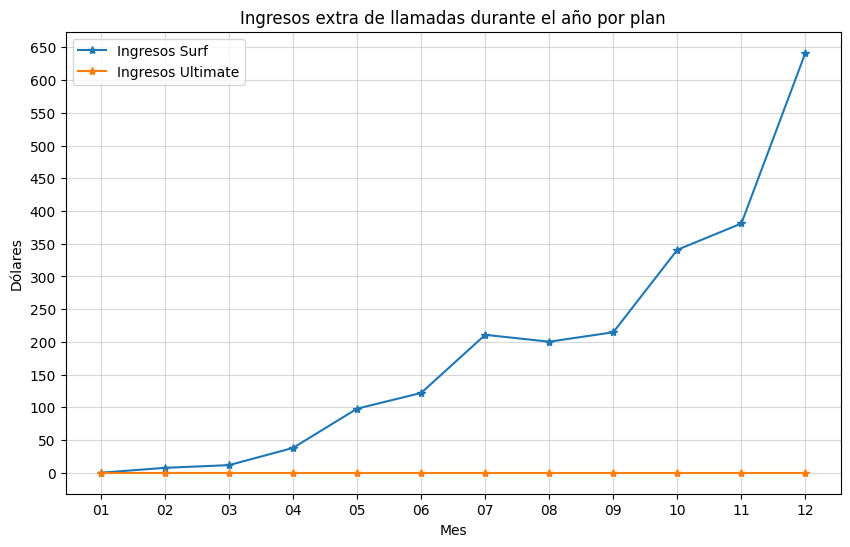

In [71]:
# Visualizo ingresos extra por llamadas.

plt.figure(figsize = (10,6))
plt.plot(df_ingresos_surf["ingresos_llamadas"], marker = "*")
plt.plot(df_ingresos_ultimate["ingresos_llamadas"], marker = "*")
plt.yticks(np.arange(0, 700, 50))
plt.legend(["Ingresos Surf", "Ingresos Ultimate"])
plt.title("Ingresos extra de llamadas durante el año por plan")
plt.xlabel("Mes")
plt.ylabel("Dólares")
plt.grid(alpha = 0.5)

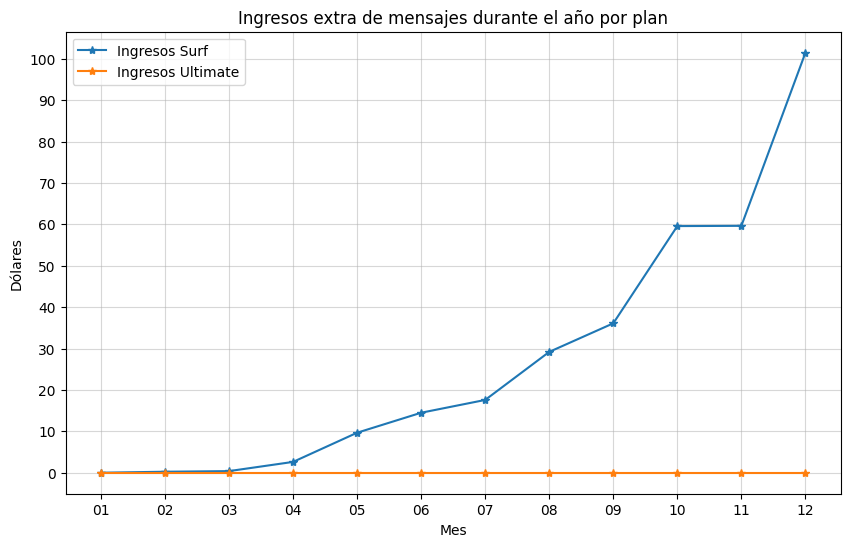

In [72]:
# Visualizo ingresos extra por mensajes.

plt.figure(figsize = (10,6))
plt.plot(df_ingresos_surf["ingresos_mensajes"], marker = "*")
plt.plot(df_ingresos_ultimate["ingresos_mensajes"], marker = "*")
plt.yticks(np.arange(0, 110, 10))
plt.legend(["Ingresos Surf", "Ingresos Ultimate"])
plt.title("Ingresos extra de mensajes durante el año por plan")
plt.xlabel("Mes")
plt.ylabel("Dólares")
plt.grid(alpha = 0.5)

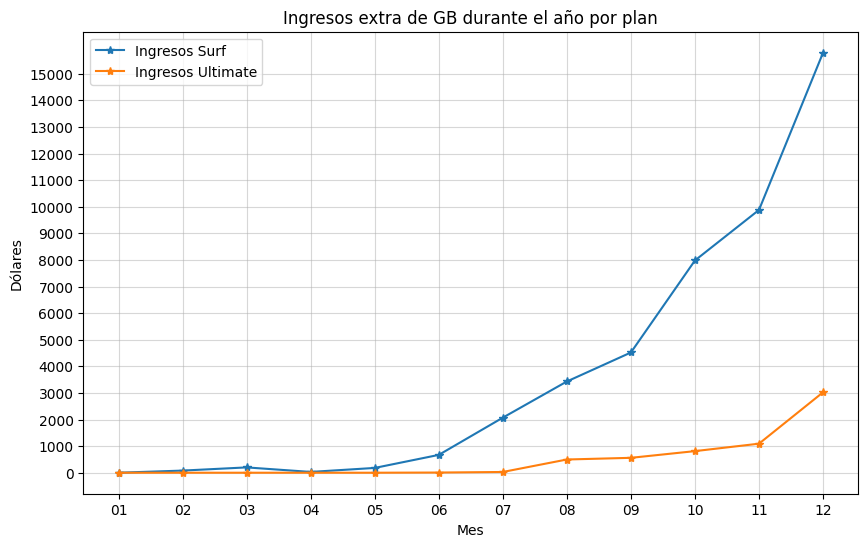

In [73]:
# Visualizo ingresos extra por MB consumidos.

plt.figure(figsize = (10,6))
plt.plot(df_ingresos_surf["ingresos_gb"], marker = "*")
plt.plot(df_ingresos_ultimate["ingresos_gb"], marker = "*")
plt.yticks(np.arange(0, 16000, 1000))
plt.legend(["Ingresos Surf", "Ingresos Ultimate"])
plt.title("Ingresos extra de GB durante el año por plan")
plt.xlabel("Mes")
plt.ylabel("Dólares")
plt.grid(alpha = 0.5)

(-0.05, 2.1)

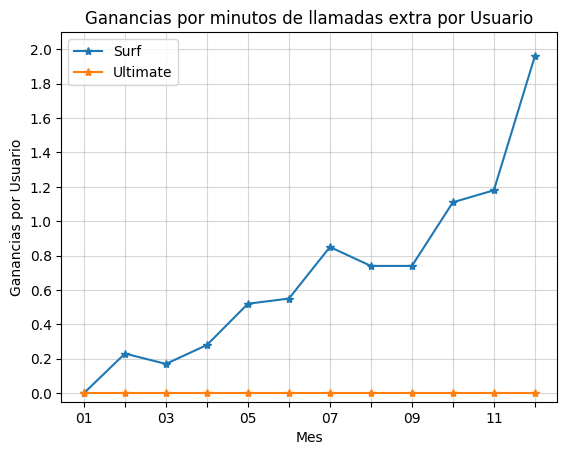

In [74]:
# Como ya había creado DF's con la información de ingresos por usuario, la vuelvo a presentar aquí para evaluarla en conjunto. Esta vez la quiero
#visualizar con líneas en lugar de barras.

# Ingreso extra per capita de llamadas.

plt_plan_month_profit = pvt_plan_month_llam_profit.plot(kind = "line", marker = "*")
plt.grid(alpha = 0.5)
plt.yticks(np.arange(0, 2.1, 0.2))
plt.xticks(np.arange(0, 12, 1))
plt.title("Ganancias por minutos de llamadas extra por Usuario")
plt.xlabel("Mes")
plt.ylabel("Ganancias por Usuario")
plt.legend(["Surf", "Ultimate"])
plt.ylim(-0.05, 2.1)

(-0.01, 0.325)

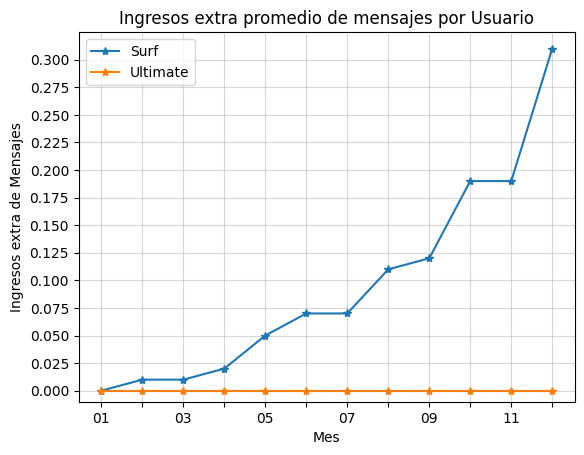

In [75]:
# Ingreso extra per capita de mensajes.

plt_plan_month_messa_profit = pvt_plan_month_messa_profit.plot(kind = "line", marker = "*")
plt.grid(alpha = 0.5)
plt.yticks(np.arange(0, 0.325, 0.025))
plt.xticks(np.arange(0, 12, 1))
plt.title("Ingresos extra promedio de mensajes por Usuario")
plt.xlabel("Mes")
plt.ylabel("Ingresos extra de Mensajes")
plt.legend(["Surf", "Ultimate"])
plt.ylim(-0.01,0.325)

(-1.0, 50.0)

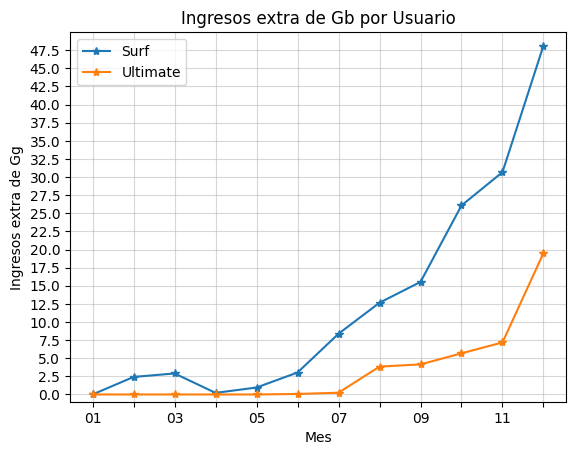

In [76]:
# Ingreso extra per capita de internet.

plt_plan_month_mb_profit = pvt_plan_month_mb_profit.plot(kind = "line", marker = "*")
plt.grid(alpha = 0.5)
plt.yticks(np.arange(0, 50, 2.5))
plt.xticks(np.arange(0, 12, 1))
plt.title("Ingresos extra de Gb por Usuario")
plt.xlabel("Mes")
plt.ylabel("Ingresos extra de Gg")
plt.legend(["Surf", "Ultimate"])
plt.ylim(-1,50)

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

- Incluso después de analizar los ingresos per capita, los usuarios de "Surf" generan más ingresos que los usuarios de "Ultimate" a pesar de ser un plan más barato como base. Esto tiene lógica, ya que el costo por el exceso es mayor y se tienen limitantes más bajas en el plan Surf que en el Ultimate.
- El mes con más ingresos sigue siendo Diciembre, lo cual tiene sentido por ser el de más actividad en llamadas, mensajes, y MB en ambos planes.
- A partir del mes de Septiembre, el plan Surf genera más ingresos que el Ultimate, ya que en los meses anteriores el Ultimate genera más ingresos solamente por tener un costo base más elevado que el de Surf.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>


Excelente elección para las visualizaciones de datos. Además, calculaste correctamente la información estadística de cada distribución de datos (minutos, mensajes e internet). Esto permite identificar patrones de comportamiento en los usuarios y extraer información valiosa para la compañía.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Respecto a la información sobre **Ingresos**, seguramente las gráficas y datos que obtuviste cambiarán cuando hagas el ajuste en el cálculo de los cobros mensuales por usuario en cada plan, entonces vale la pena revisar si tu análisis deba ser ajustado también.

</div>
</div>

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [77]:
# Prueba las hipótesis

# H0: Los ingresos promedio del plan Surf son iguales a los del plan Ultimate.
# H1: Los ingresos promedio del plan Surf y los del plan Ultimate son diferentes.

# Esta prueba es de 2 colas porque no se especifica si tiene que ser mayor o menor, solo diferente.

from scipy.stats import t, ttest_ind

# Tolerancia de 5.00%
alpha = 0.05

ingresos_totales_surf = data_summary_final[data_summary_final["plan"] == "surf"]["ingresos_totales"]
ingresos_totales_ultimate = data_summary_final[data_summary_final["plan"] == "ultimate"]["ingresos_totales"]

# Uso el test de 2 colas especificando que estos grupos no tienen la misma varianza, como ya habíamos revisado anteriormente.
t_stat, p_val_2tail = ttest_ind(ingresos_totales_surf, ingresos_totales_ultimate, equal_var = False)

print(f"t-statistic: {round(t_stat, 2)}")
print(f"p-value: {p_val_2tail}")
print()
if p_val_2tail < alpha:
    print("""Se \033[1mrechaza\033[0m la hipótesis nula y se acepta la alternativa:
    Los ingresos promedios de los 2 planes son diferentes.""")
else:
    print("""\033[1mNo se rechaza\033[0m la hipótesis nula:
    No hay suficientes evidencias para concluir que los ingersos promedios de los 2 planes sean diferentes.""")

print()

t-statistic: -20.66
p-value: 1.3691696093620412e-89

Se rechaza la hipótesis nula y se acepta la alternativa:
    Los ingresos promedios de los 2 planes son diferentes.



[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [78]:
# Agrego la columna "state" que había creado anteriormente para esta prueba.

data_summary_region = data_summary_final.merge(df_users[["user_id", "state"]], on = "user_id")
filtro_nynj = data_summary_region[data_summary_region["state"].str.contains("NY-NJ")]
filtro_not_nynj = data_summary_region[~data_summary_region["state"].str.contains("NY-NJ")]
data_summary_region.sample(5)

,user_id,plan,month,call_count,duration,message_count,gb_used,ingresos_llamadas,ingresos_mensajes,ingresos_gb,usd_monthly_pay,ingresos_totales,state
2673,1315,surf,11,26,274.0,21,8.0,0.00,0.00,0.0,20.0,20.00,NC
3037,1381,surf,09,21,179.0,63,13.0,0.00,0.39,0.0,20.0,20.39,TX
2230,1222,surf,12,73,623.0,24,6.0,3.69,0.00,0.0,20.0,23.69,CA
2153,1207,surf,09,0,0.0,0,1.0,0.00,0.00,0.0,20.0,20.00,NE-IA
1804,1138,surf,08,60,542.0,7,6.0,1.26,0.00,0.0,20.0,21.26,CA


In [79]:
# Prueba las hipótesis

# H0: Los ingresos promedio de los usuarios de NY-NJ son iguales a los del resto.
# H1: Los ingresos promedio del plan Surf y los del plan Ultimate son diferentes.

# Esta prueba es de 2 colas porque no se especifica si tiene que ser mayor o menor, solo diferente.

# Tolerancia de 5.00%
alpha = 0.05

ingresos_totales_all = filtro_not_nynj["ingresos_totales"]
ingresos_totales_nynj = filtro_nynj["ingresos_totales"]

# Uso el test de 2 colas especificando que la varianza es diferente porque no sé si lo es o no.
t_stat, p_val_2tail = ttest_ind(ingresos_totales_nynj, ingresos_totales_all, equal_var = False)

print(f"t-statistic: {round(t_stat, 2)}")
print(f"p-value: {p_val_2tail}")
print()
if p_val_2tail < alpha:
    print("""Se \033[1mrechaza\033[0m la hipótesis nula y se acepta la alternativa:
    Los ingresos promedios de NY-NJ son diferentes.""")
else:
    print("""\033[1mNo se rechaza\033[0m la hipótesis nula:
    No hay suficientes evidencias para concluir que los ingersos promedios de NY-NJ sean diferentes.""")

print()

t-statistic: -7.61
p-value: 4.875805599531943e-14

Se rechaza la hipótesis nula y se acepta la alternativa:
    Los ingresos promedios de NY-NJ son diferentes.



<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Ricardo aplicaste correctamente las pruebas de hipótesis comparando la distribución de dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo realizar previamente una prueba de  [Levene](https://www.educaopen.com/digital-lab/blog/educacion-digital/prueba-de-levene) para evaluar la igualdad de las varianzas, lo que te permitirá configurar adecuadamente el parámetro **equal_var** en la función `ttest_ind`. Esto te brindará una interpretación más precisa de los resultados además garantizará que la prueba t sea estadísticamente válida.

</div>
</div>

## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

- Los usuarios de ambos planes consumen más llamadas, mensajes, y MB conforme avanza el año. Esto se concluye sin ignorar que el número de usuarios incrementó durante el año, ya que esto no influyó en el uso por usuario, solamente en el uso total.
- El plan Surf genera más ingresos en promedio que el Ultimate si se evalua el año completo. Mes a mes, el plan Ultimate genera más ingresos hasta el mes de Agosto, y el de Surf a partir de Septiembre genera más en total, pero debe de mencionarse que el plan Surf tiene más usuarios que el plan Ultimate.
- En general, los del plan Ultimate no se exceden de sus límites salvo por los MB al final del año, mientras que los de Surf sí se exceden en llamadas, mensajes, y datos de internet.
- Para la empresa, lo ideal sería que todos los usuarios tengan el plan Ultimate por 8 meses y que luego todos cambiaran al plan Surf para maximizar los ingresos. Para los usuarios, lo ideal sería la inversa para pagar lo menos posible.
- Los mensajes son el beneficio menos utilizado por los usuarios, y los usuarios que se exceden de Surf lo hacen por muy poco.
- Según las pruebas de hipótesis, en general los usuarios de Surf generan menos ingresos que los de Ultimate (indicado por el t-stat negativo), y de igual manera los usuarios de NY-NJ generan menos ingresos que el resto de las ciudades de la muestra.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Tu conclusión va alineada con la información que has obtenido en el proyecto. Aunque presentas una interpretación correcta, es importante revisar tu conclusión luego de hacer los ajustes que te mencioné más arriba, en en caso de que los valores hayan cambiado significativamente.

</div>

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

Después de hacer las revisiones, el resultado de mi análisis es el mismo. ¡Gracias!

</div>